 ### __Download and preprocess tweets.txt__

In [1]:
from src.data_utils import download_tweets, clean_tweets, partition_into_train_test

In [2]:
#Downloading tweets.txt:
url = "https://code.s3.yandex.net/deep-learning/tweets.txt"
save_path = "data/tweets.txt"
download_tweets(url, save_path)

In [3]:
#Create cleaned_tweets_csv:
frac = 0.001 
clean_tweets(frac)

In [4]:
#Train-val-test partitioning
partition_into_train_test()

/home/malgepav/Code/YandexPracticum/Sprint2/YP-sprint2-project-text_autocomplete_malgepav/src/data_utils.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tweets_df["begining"] = tweets_df["tokens"].apply(
/home/malgepav/Code/YandexPracticum/Sprint2/YP-sprint2-project-text_autocomplete_malgepav/src/data_utils.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tweets_df["ending"] = tweets_df["tokens"].apply(
/home/malgepav/Code/YandexPracticum/Sprint2/YP-sprint2-project-text_autocomplete_malgepav/src/da

### __Training and validation datasets Creation__

In [5]:
from transformers import AutoTokenizer

/home/malgepav/Code/YandexPracticum/Sprint2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from src.next_token_dataset import create_next_token_dataset_from_csv
from src.seq_generation_dataset import create_seq_gen_dataset_from_csv

In [7]:
tokenizer_model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_model_name)

In [8]:
train_dataset = create_next_token_dataset_from_csv("data/train_tweets.csv", tokenizer)

In [9]:
val_dataset = create_seq_gen_dataset_from_csv("data/val_tweets.csv")

### __Training and validation dataloaders Creation__

In [10]:
import torch
from src.next_token_dataset import get_next_token_collate_fn
from src.seq_generation_dataset import seq_gen_collate_fn
from torch.utils.data import DataLoader

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [12]:
train_loader = DataLoader(train_dataset,
                          batch_size=32,
                          collate_fn=get_next_token_collate_fn(tokenizer),
                         shuffle=True)

In [13]:
val_loader = DataLoader(val_dataset,
                          batch_size=512,
                          collate_fn=seq_gen_collate_fn,
                         shuffle=False)

### __Model Creation__

In [14]:
from src.lstm_model import TextAutoCompleteLSTM

In [15]:
input_dim  = 10
hidden_dim = 5
dropout = 0.1
bidirecttional = True
num_layers = 2

In [16]:
model = TextAutoCompleteLSTM(input_dim=input_dim,
                             hidden_dim=hidden_dim,
                             dropout=dropout,
                             tokenizer=tokenizer,
                             num_layers=num_layers,
                             bidirectional=bidirecttional,
                            device = device).to(device)


### __Model Training__

In [17]:
import torch.nn as nn
import torch.optim as optim
from src.lstm_train import train_epoch
from src.eval_lstm import model_eval_metrics

In [20]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)
num_epochs = 3

In [19]:
train_losses = []
rouge1 = []
rouge2 = []

In [21]:
for epoch in range(1, num_epochs+1):
    print(f"Epoch {epoch}: training")
    epoch_loss = train_epoch(model=model,
                train_loader=train_loader,
                loss_fn=loss_fn, optimizer=optimizer,
                epoch=epoch,
                device=device)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch}: validation")
    rouge1_epoch, rouge2_epoch = model_eval_metrics(model=model,
                                                    loader=val_loader,
                                                      tokenizer=tokenizer,
                                                        device=device)
    rouge1.append(rouge1_epoch)
    rouge2.append(rouge2_epoch)
    print(f"Epoch {epoch}: loss = {epoch_loss:.4f}, rouge1 = {rouge1_epoch:.4f}, rouge2 = {rouge2_epoch:.4f}")

    checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'losses': train_losses,
    'rogue1': rouge1,
    'rogue2': rouge2
    }
    torch.save(checkpoint, f'models/checkpoint_epoch{epoch}.pth')


Epoch 1: training


Epoch 1:: 100%|██████████| 40/40 [00:08<00:00,  4.61it/s]


Epoch 1: validation


100%|██████████| 1/1 [00:00<00:00,  1.08it/s]


Epoch 1: loss = 10.0514, rouge1 = 0.0365, rouge2 = 0.0030
Epoch 2: training


...

Epoch 2: loss = 9.0225, rouge1 = 0.0365, rouge2 = 0.0030
Epoch 3: training


Epoch 3:: 100%|██████████| 40/40 [00:07<00:00,  5.25it/s]


Epoch 3: validation


100%|██████████| 1/1 [00:00<00:00,  1.37it/s]

Epoch 3: loss = 7.8396, rouge1 = 0.0365, rouge2 = 0.0030


### __Plot metrics__

In [22]:
import matplotlib.pyplot as plt

In [23]:
plt.style.use("ggplot")

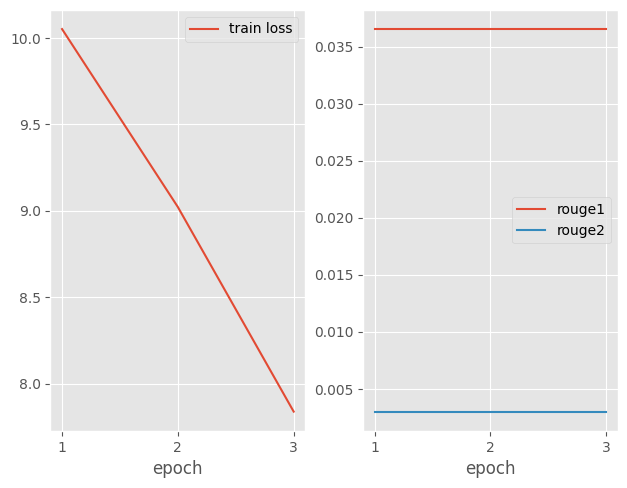

In [40]:
fig, (ax1, ax2) = plt.subplots(1,2)
plt.tight_layout()
ax1.plot(list(range(1,num_epochs+1)),train_losses, label="train loss")
ax1.set_xticks(list(range(1,num_epochs+1)))
ax1.set_xlabel("epoch")
ax1.legend()
ax1.grid(True)

ax2.plot(list(range(1,num_epochs+1)),rouge1, label="rouge1")
ax2.plot(list(range(1,num_epochs+1)),rouge2, label="rouge2")
ax2.set_xticks(list(range(1,num_epochs+1)))
ax2.set_xlabel("epoch")
ax2.legend()
ax2.grid(True)

plt.show()

#### __Example of text autocompletion__

In [25]:
from random import randint

In [26]:
for i in range(5):
    index = randint(0,len(val_dataset)-1)
    begining, ending = val_dataset.__getitem__(index)
    begining_tokenized  = tokenizer(begining, return_tensors="pt")
    generated_ending = model.generate(max_new_tokens=len(ending.split()),
                                      **begining_tokenized)
    decoded = tokenizer.decode(generated_ending[0], skip_special_tokens=True)         
    print(f"Example {i+1}:")      
    print("Begining: |"+begining+'|')
    print("Original ending: |"+ending+'|')
    print("Generated: |"+decoded+'|')
    print('-'*30)

Example 1:
Begining: |looking through warranty for #eee pc. battery failed and i have to|
Original ending: |send it back for replacement/repair.|
Generated: |looking through warranty for # eee pc. battery failed and i have to i i i i i|
------------------------------
Example 2:
Begining: |hey! good luck with your race for life! i'm doing|
Original ending: |mine on 21st june|
Generated: |hey! good luck with your race for life! i ' m doing i i i i|
------------------------------
Example 3:
Begining: |on the way to gibson fixen to take on a 3 hour|
Original ending: |drive and the play ball|
Generated: |on the way to gibson fixen to take on a 3 hour i i i i i|
------------------------------
Example 4:
Begining: |haha. malay ko ba. year of the pig din|
Original ending: |nung 2007 kaya.|
Generated: |haha. malay ko ba. year of the pig din i i i|
------------------------------
Example 5:
Begining: |hey! school... sucked! eugh. i got|
Original ending: |another assignment.|
Generated: |hey! scho

### __Pretrained Transformer__

In [27]:
from transformers import AutoModelForCausalLM

model_name = "distilgpt2"

gpt2_tokenizer = AutoTokenizer.from_pretrained(model_name)
gpt2_model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

In [28]:
r1, r2 = model_eval_metrics(model = gpt2_model,
                            loader=val_loader,
                            tokenizer=gpt2_tokenizer,
                            device=device
                            )


100%|██████████| 1/1 [00:16<00:00, 16.22s/it]


In [29]:
print("Transformer rouge scores:")
print(f"Rouge1: {r1:.4f}, Rouge2: {r2:.4f}")


Transformer rouge scores:
Rouge1: 0.0680, Rouge2: 0.0048


#### __Transformer text autocompletion examples___

In [30]:
for i in range(5):
        index = randint(0,len(val_dataset)-1)
        begining, ending = val_dataset.__getitem__(index)
        begining_tokenized  = gpt2_tokenizer(begining, return_tensors="pt")
        generated_ending = gpt2_model.generate(**begining_tokenized, 
                                               pad_token_id=gpt2_tokenizer.eos_token_id, 
                                               max_new_tokens=len(ending.split()))
        decoded = gpt2_tokenizer.decode(generated_ending[0], skip_special_tokens=True)         
        print(f"Example {i+1}:")      
        print("Begining: "+begining)
        print("Original ending: "+ending)
        print("Generated ending: "+decoded.removeprefix(begining))
        print('-'*30)
    

Example 1:
Begining: i'll be working til ten oclock tonight. i love
Original ending: her. forever and always
Generated ending:  it. i love
------------------------------
Example 2:
Begining: oh well i
Original ending: was concerneded.
Generated ending:  think i
------------------------------
Example 3:
Begining: mr. kebab sounds good
Original ending: tonight. hmm
Generated ending: .

------------------------------
Example 4:
Begining: i fn hate dell. i miss
Original ending: my mac
Generated ending:  a lot
------------------------------
Example 5:
Begining: weather: yesterday's adventures!!: the weather was nice for the art awards the
Original ending: opening of the show wa..
Generated ending:  day before, and the
------------------------------
